### 05-02-02. 선형 SVM의 장단점

- **장점**
    - 간단하고 효율적이다.
    - 고차원 데이터에서도 효과적이다.
- **단점**
    - 데이터가 선형적으로 분리되지 않는 경우 성능이 저하된다.

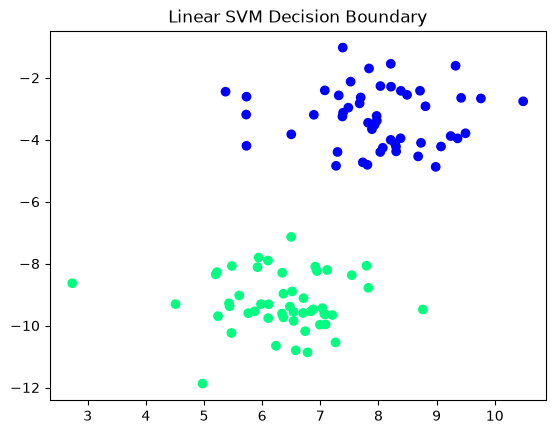

In [3]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs     # 군집 나누는
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=100, centers=2, random_state=6) # 2개의 군집 생성

# 선형 SVM 모델 학습
model = SVC(kernel='linear')
model.fit(X, y)

# 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.title("Linear SVM Decision Boundary")
plt.show()

### 05-03-03. 비선형 SVM 장단점

- **장점**
    - 선형적으로 구분되지 않는 데이터를 잘 처리한다.
    - 다양한 커널 함수로 유연성이 높다.
- **단점**
    - 계산 비용이 높다.
    - 커널 및 하이퍼파라미터 선택이 중요하다.

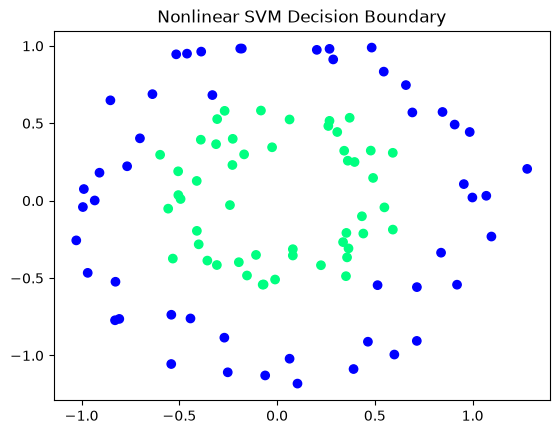

In [4]:
from sklearn.svm import SVC
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_circles(n_samples=100, factor=0.5, noise=0.1)

# 비선형 SVM 모델 학습 (RBF 커널)
model = SVC(
    kernel='rbf',   # 가우시안 커널(비선형)
    gamma=1)        # 결정 경계의 굴곡 정도
model.fit(X, y)

# 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
plt.title("Nonlinear SVM Decision Boundary")
plt.show()

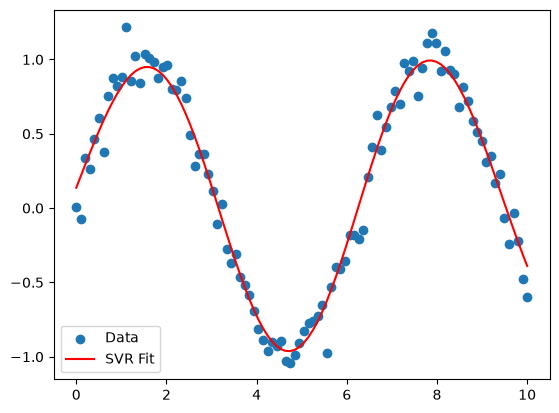

In [10]:
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

# 데이터 생성
X = np.linspace(0, 10, 100).reshape(-1, 1)  # reshape(-1, 1)로 2차원 배열로 변환
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])    # 사인함수 + 노이즈 추가

# SVM 회귀 모델 학습
model = SVR(
    kernel='rbf',       # 비선형
    C=1,                # 오차에 대한 패널티 강도(오차를 얼마나 허용할지 : 경계의 모양)
                        # C 값을 크게주면 100~ 1000 경계가 구불구불(과적합). 작게 주면 경계가 부드러움(과소적함)
    epsilon=0.1)        # 오차 허용 구간 (오차라고 보지않을 허용범위 폭)
model.fit(X, y)

# 예측 및 시각화
y_pred = model.predict(X)
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color='red', label="SVR Fit")
plt.legend()
plt.show()